In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression



rng = np.random.default_rng(42)

n = 300

df = pd.DataFrame({
    "age": rng.integers(1, 70, n),
    "temp_c": rng.uniform(36.0, 40.5, n),
    "parasite_density": rng.integers(0, 500, n),
    "bednet_use": rng.choice([0, 1], n) # 1 = uses bednet, 0 = no
})

#Risk Score -> probability -> target (sigmoid)

risk = 0.2*(df["temp_c"] - 37.0) + 0.005*df["parasite_density"] - 0.4*df["bednet_use"]
prob = 1 / (1+ np.exp(-(risk - 0.5)))
df["malaria_positive"] = (rng.uniform(0, 1, n) < prob).astype(int)


df.head()


,age,temp_c,parasite_density,bednet_use,malaria_positive
0,7,39.718314,2,1,1
1,54,40.032723,21,0,1
2,46,36.631121,109,1,1
3,31,38.493163,442,1,1
4,30,36.488591,229,1,0


C:\Users\user\AppData\Local\Temp\ipykernel_20920\1229718060.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  malaria_rate_by_age = df.groupby("age_group")["malaria_positive"].mean()


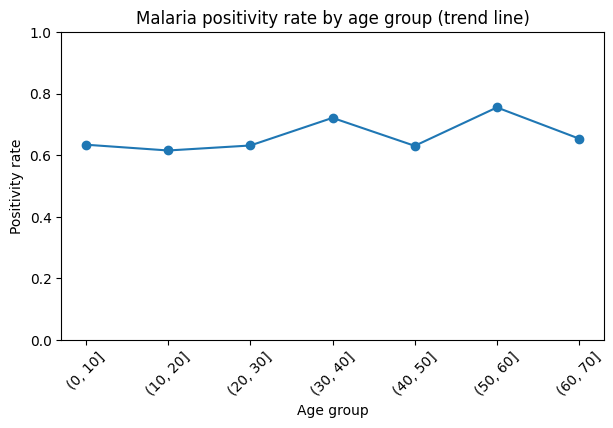

In [3]:
#3) visualization for Class: line plot + Bar Chart

df["age_group"] = pd.cut(df["age"], bins=[0, 10, 20, 30, 40, 50, 60, 70], right=True)

malaria_rate_by_age = df.groupby("age_group")["malaria_positive"].mean()


plt.figure(figsize=(7,4))
plt.plot(malaria_rate_by_age.index.astype(str), malaria_rate_by_age.values, marker="o")
plt.title("Malaria positivity rate by age group (trend line)")
plt.xlabel("Age group")
plt.ylabel("Positivity rate")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()



In [5]:
X = df[["age", "temp_c", "parasite_density", "bednet_use"]]
y = df["malaria_positive"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y)

print(X_train.shape, X_test.shape)

(225, 4) (75, 4)


In [7]:
from sklearn.metrics import roc_auc_score

#Logistic Regression (Coefficients)

logreg = LogisticRegression(max_iter=500)
logreg.fit(X_train, y_train)

#Probabilities for ROC AUC

y_proba = logreg.predict_proba(X_test)[:, 1]
y_pred = logreg.predict(X_test)


print("Test ROC-AUC (LogReg):", roc_auc_score(y_test, y_proba))
print("\nClassification report(logReg):\n", classification_report(y_test, y_pred))


Test ROC-AUC (LogReg): 0.7423999999999998

Classification report(logReg):
               precision    recall  f1-score   support

           0       0.67      0.32      0.43        25
           1       0.73      0.92      0.81        50

    accuracy                           0.72        75
   macro avg       0.70      0.62      0.62        75
weighted avg       0.71      0.72      0.69        75



In [9]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": logreg.coef_[0]

}).sort_values("coefficient", ascending=False)


print(coef_df)

            feature  coefficient
1            temp_c     0.318121
2  parasite_density     0.003943
0               age     0.000584
3        bednet_use    -0.272273


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=44)
cv_scores = cross_val_score(logreg, X, y, cv=cv, scoring="roc_auc")


print("CV ROC-AUC scores:", cv_scores)

print("Mean CV ROC-AUC:", cv_scores.mean())

CV ROC-AUC scores: [0.75481386 0.7025     0.6725     0.63375    0.67125   ]
Mean CV ROC-AUC: 0.6869627727856227


In [12]:
#Decision tree (Feature Importance)

tree = DecisionTreeClassifier(random_state=44, max_depth=4)
tree.fit(X_train, y_train)

tree_proba = tree.predict_proba(X_test)[:, 1]
tree_pred = tree.predict(X_test)

print("Test ROC-AUC (Tree):", roc_auc_score(y_test, tree_proba))
print("\nClassification report (Tree):\n", classification_report(y_test, tree_pred))

Test ROC-AUC (Tree): 0.7216

Classification report (Tree):
               precision    recall  f1-score   support

           0       0.45      0.36      0.40        25
           1       0.71      0.78      0.74        50

    accuracy                           0.64        75
   macro avg       0.58      0.57      0.57        75
weighted avg       0.62      0.64      0.63        75



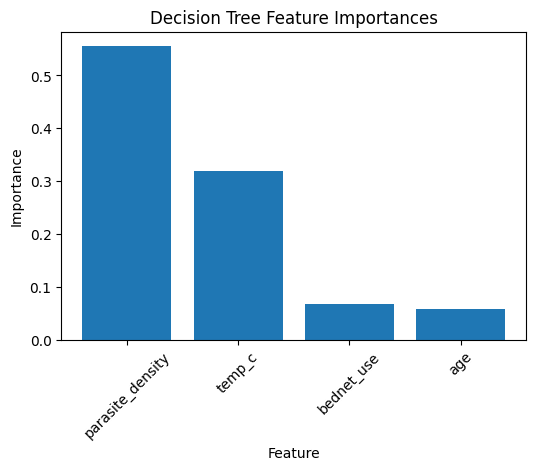

In [13]:
importances = pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(6, 4))
plt.bar(importances.index, importances.values)
plt.title("Decision Tree Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()